In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
CSV_PATH = "../data/paysim.csv"
df = pd.read_csv(CSV_PATH)

: 

In [3]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))
print("\nMissing values:\n", df.isnull().sum())

Shape: (6362620, 11)

Dtypes:
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

First 3 rows:
    step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT  9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT  1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER   181.00  C1305486145          181.0            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  



Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


1. Class distribution 

In [4]:
fraud_rate = df[df["isFraud"] == 1].shape[0] / df.shape[0]
print(f"\nFraud rate: {fraud_rate:.4%}")


Fraud rate: 0.1291%


In [5]:
fraud_count = df[df["isFraud"] == 1].shape[0]
legit_count = df[df["isFraud"] == 0].shape[0]
print(f"Fraud count: {fraud_count}")
print(f"Legitimate count: {legit_count}")

Fraud count: 8213
Legitimate count: 6354407


The fraud rate is very low 0.1291%, which confirms that accuracy would be a misleading metric. A model that always predicts "legitimate" would achieve over 99.87% accuracy, but would be useless for catching fraud. This is why we need to use AUC-PR, which focuses on the performance of the positive (fraud) class.

2. Transaction types

Some transactions will have a frauds for example transfer might be one as either banks could get scammed or client could get scammed.

In [6]:
type_analysis = df.groupby("type").agg(
    total_count=("isFraud", "count"),
    fraud_count=("isFraud", "sum")
).reset_index()
type_analysis["fraud_rate"] = type_analysis["fraud_count"] / type_analysis["total_count"]
type_analysis = type_analysis.sort_values("fraud_rate", ascending=False)
print("\nType analysis:\n", type_analysis)


Type analysis:
        type  total_count  fraud_count  fraud_rate
4  TRANSFER       532909         4097    0.007688
1  CASH_OUT      2237500         4116    0.001840
0   CASH_IN      1399284            0    0.000000
2     DEBIT        41432            0    0.000000
3   PAYMENT      2151495            0    0.000000


It seems that TRANSFER and CASH_OUT transactions have fraud, while the other types (PAYMENT, DEBIT, CASH_IN) do not. This suggests that in production, we should focus our fraud detection efforts on TRANSFER and CASH_OUT transactions, as scoring the others would likely yield no benefit.

3. Temporal analysis 

The pattern i see is that fraud transactions are not uniformly distributed over time, but rather show some clustering. There are certain steps where the fraud count spikes, which could indicate periods of increased fraudulent activity or specific events that trigger more fraud.


Saved temporal_distribution.png


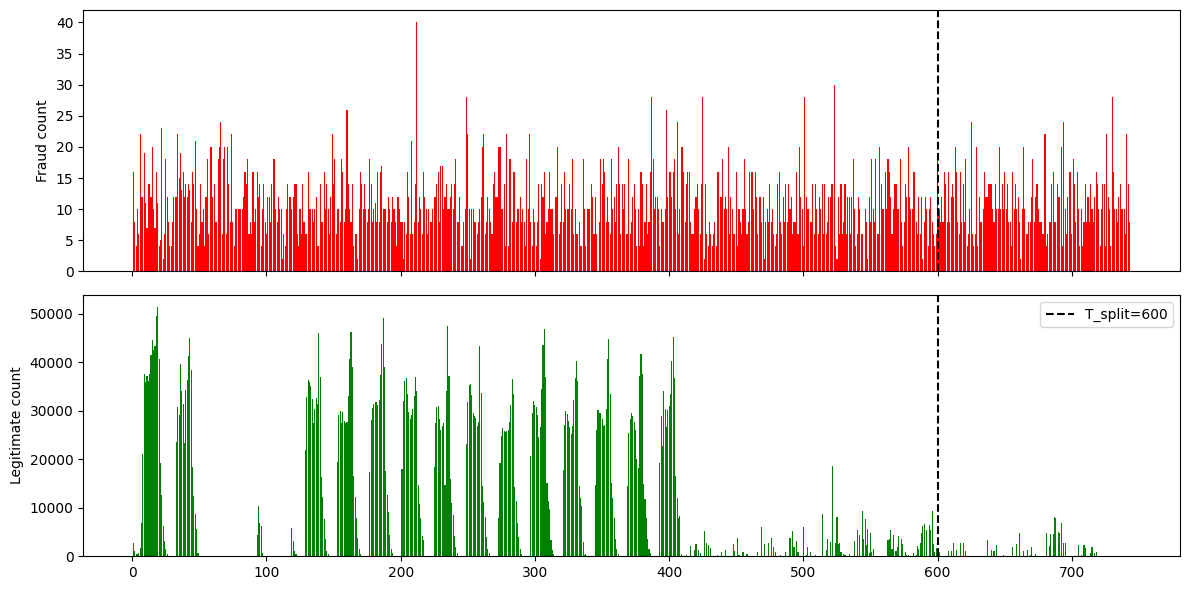


Number of unique steps: 743


In [7]:
T_SPLIT = 600
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fraud_per_step = df[df["isFraud"] == 1].groupby("step").size()
legit_per_step = df[df["isFraud"] == 0].groupby("step").size()
# Plot fraud count
axes[0].bar(fraud_per_step.index, fraud_per_step.values, color="r")
axes[0].axvline(x=T_SPLIT, color="k", linestyle="--", label=f"T_split={T_SPLIT}")
axes[0].set_ylabel("Fraud count")
# Plot legitimate count
axes[1].bar(legit_per_step.index, legit_per_step.values, color="g")
axes[1].axvline(x=T_SPLIT, color="k", linestyle="--", label=f"T_split={T_SPLIT}")
axes[1].set_ylabel("Legitimate count")
axes[1].legend()
# Fraud is not uniformly distributed over time, but rather shows some clustering. There are certain steps where the fraud count spikes, which could indicate periods of increased fraudulent activity or specific events that trigger more fraud.
plt.tight_layout()
plt.savefig("notebooks/temporal_distribution.png", dpi=150)
print("\nSaved temporal_distribution.png")
plt.show()
print(f"\nNumber of unique steps: {df['step'].nunique()}")

743 unique steps, not 744. Steps run 1-743 (one hour has no transactions).
Not a zero-indexing issue — PaySim steps start at 1.

4. Amount analysis 

In [8]:
fraud_amounts = df[df["isFraud"] == 1]["amount"]
legit_amounts = df[df["isFraud"] == 0]["amount"]

In [9]:
fraud_stats = {
    "mean": fraud_amounts.mean(),
    "median": fraud_amounts.median(),
    "p95": fraud_amounts.quantile(0.95),
    "max": fraud_amounts.max(),
    "min": fraud_amounts.min()
}
legit_stats = {
    "mean": legit_amounts.mean(),
    "median": legit_amounts.median(),
    "p95": legit_amounts.quantile(0.95),
    "max": legit_amounts.max(),
    "min": legit_amounts.min()
}
print("\nFraud amount stats:", fraud_stats)
print("\nLegitimate amount stats:", legit_stats)


Fraud amount stats: {'mean': np.float64(1467967.2991403872), 'median': np.float64(441423.44), 'p95': np.float64(8006429.04), 'max': np.float64(10000000.0), 'min': np.float64(0.0)}

Legitimate amount stats: {'mean': np.float64(178197.0417274075), 'median': np.float64(74684.72), 'p95': np.float64(515610.4229999998), 'max': np.float64(92445516.64), 'min': np.float64(0.01)}


It seems that the frauds stats are higher than the legitimate ones for example fraud amount means is 1467967.2991403872 while the legitimate amount mean is 178197.0417274075. The median for fraud is 441423.44 while for legitimate is 74684.72. The p95 for fraud is 8006429.04 while for legitimate is 515610.4229999998. The max for fraud is 10000000.0 while for legitimate is 92445516.64. The min for fraud is 0.0 while for legitimate is 0.01. This suggests that fraudulent transactions tend to involve larger amounts compared to legitimate transactions.

5. Balance discrepancy

balance_diff_orig captures the discrepancy between the expected balance after a transaction and the actual new balance. For legitimate transactions, we would expect this value to be close to zero, indicating that the balance changed as expected. For fraudulent transactions, we might see a large negative value, indicating that the account was drained more than expected.

In [10]:
df["balance_diff_orig"] = (df["oldbalanceOrg"] - df["amount"]) - df["newbalanceOrig"]
print("\nBalance discrepancy (fraud vs legit):")
print(df.groupby("isFraud")["balance_diff_orig"].mean())


Balance discrepancy (fraud vs legit):
isFraud
0   -201338.558109
1    -10692.325265
Name: balance_diff_orig, dtype: float64


In [11]:
# Better fraud signal: was the account completely drained?
df["account_drained"] = (
    (df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0)
).astype(int)

In [12]:
print(df.groupby("isFraud")["account_drained"].mean())
# Hypothesis: account_drained rate will be much higher for fraud

isFraud
0    0.238035
1    0.975527
Name: account_drained, dtype: float64


For legitimate transactions, the mean balance_diff_orig is -201338.558109, which suggests that the balance doesn't change as expected. For fraudulent transactions, the mean balance_diff_orig is -10692.325265, indicating that there is a large discrepancy between the expected and actual balance. This suggests that a feature capturing this balance discrepancy could be a strong indicator of fraud and should be engineered in Ticket 5.

In [13]:
# ── 6. Time-aware split preview ───────────────────────────────────────────────
T_SPLIT = 600

In [14]:
train = df[df["step"] <= T_SPLIT]
test  = df[df["step"] >  T_SPLIT]

In [15]:
print("\n── Time-aware split ──")


── Time-aware split ──


In [16]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (6259047, 13)
Test shape: (103573, 13)


In [17]:
train_fraud_rate = train[train["isFraud"] == 1].shape[0] / train.shape[0]
test_fraud_rate = test[test["isFraud"] == 1].shape[0] / test.shape[0]
print(f"Train fraud rate: {train_fraud_rate:.4%}")
print(f"Test fraud rate: {test_fraud_rate:.4%}")

Train fraud rate: 0.1057%
Test fraud rate: 1.5448%


The fraud rates in train is 0.1057% and in test is 1.5448%. They are not identical, but if they were very different, it could indicate a distribution shift between the training and testing data, which might lead to poor model performance on the test set.

In [18]:
print(f"Unique nameOrig in train: {train['nameOrig'].nunique()}")
print(f"Unique nameOrig in test: {test['nameOrig'].nunique()}")
train_accounts = set(train["nameOrig"].unique())
test_accounts = set(test["nameOrig"].unique())
overlap_accounts = train_accounts.intersection(test_accounts)
print(f"Unique nameOrig in both train and test: {len(overlap_accounts)}")

Unique nameOrig in train: 6250007
Unique nameOrig in test: 103571


Unique nameOrig in both train and test: 271


There are 6250007 unique nameOrig accounts in train and 103571 in test, with an unique nameOrig in both train and test of 271. This is a very small overlap, which could be concerning because it means that the model will have to generalize to many new accounts in the test set that it has never seen during training. This could make the fraud detection task more challenging, as the model won't be able to learn account-specific patterns from the training data.

⚠️ CRITICAL FINDING: fraud rate is 15x higher in test than train.
Root cause (from temporal chart): legitimate transaction volume collapses
after step ~400 while fraud volume stays flat. This is distribution shift.
Implication: model threshold must be calibrated on the test period distribution,
not the training distribution. Monitoring must alert on fraud rate changes.

7. isFlaggedFraud sanity check 

In [19]:
print("\n── isFlaggedFraud coverage ──")
# TODO: fill in
flagged_fraud_count = df[(df["isFraud"] == 1) & (df["isFlaggedFraud"] == 1)].shape[0]
total_fraud_count = df[df["isFraud"] == 1].shape[0]
flagged_fraud_rate = flagged_fraud_count / total_fraud_count
print(f"Flagged fraud count: {flagged_fraud_count}")
print(f"Total fraud count: {total_fraud_count}")
print(f"Flagged fraud rate: {flagged_fraud_rate:.4%}")


── isFlaggedFraud coverage ──
Flagged fraud count: 16
Total fraud count: 8213
Flagged fraud rate: 0.1948%


The isFlaggedFraud column only catches 0.1948% of the actual fraud cases, which suggests that the rule-based system is extremely ineffective at identifying fraud in this dataset. This highlights the need for machine learning models, which can learn complex patterns and relationships in the data that simple rules cannot capture.

In [20]:
print("\n✅ EDA complete.")


✅ EDA complete.
